# Naive Bayes no Python
Podemos usar vários modelos de Naive Bayes no `sklearn.naive_bayes`:
* `GaussianNB`: usa a distribuição normal
* `MultinomialNB`: usa a distribuição _multinomial_, que é uma generalização da binomial.
* `ComplementNB`: adaptação da distribuição multinomial feita para dados não balanceados.
* `BernoulliNB`: cada variável é binária (pode ser usado para variáveis categóricas depois de binarizar).
* `CategoricalNB`: para dados categóricos.

O esquema continua o mesmo:
1. Instanciamos o modelo em uma variável `modelo(parâmetros)`.
2. Usamos `modelo.fit(X_treino, y_treino)` para treinar o modelo.
3. Usamos `modelo.predict(X_teste)` para avaliar o modelo.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

Como antes, vamos exportar os dados do R no Python.

In [ ]:
%load_ext rpy2.ipython

In [ ]:
iris = %R iris
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Sepal.Length  150 non-null    float64 
 1   Sepal.Width   150 non-null    float64 
 2   Petal.Length  150 non-null    float64 
 3   Petal.Width   150 non-null    float64 
 4   Species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 6.1+ KB


A tática vai ser a mesma:
1. Separamos `y` (o que queremos prever) de `X` (o que usamos para a previsão)
2. Usamos `train_test_split` para separar em treino e teste.
3. Instanciamos o modelo (uma classe).
4. Usamos `modelo.fit(X_train, y_train)` para treinar o modelo.
5. Usamos `modelo.predict(X_test)` para testar o modelo.
6. Usamos as métricas para avaliar o modelo.

In [ ]:
# 1. Separamos y (o que queremos prever)
#    de X (o que usamos para a previsão)
y = iris["Species"]
X = iris.drop("Species", axis=1)

In [ ]:
# 2. Usamos train_test_split para separar em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
# 3. Instanciamos o modelo (uma classe)
iris_nb = GaussianNB()

In [ ]:
# 4. Usamos modelo.fit(X_train, y_train) para treinar o modelo
iris_nb = iris_nb.fit(X_train, y_train)

In [ ]:
# 5. Usamos modelo.predict(X_test) para testar o modelo
iris_pred = iris_nb.predict(X_test)

In [ ]:
iris_pred

array(['virginica', 'versicolor', 'virginica', 'versicolor', 'virginica',
       'virginica', 'virginica', 'versicolor', 'setosa', 'setosa',
       'virginica', 'versicolor', 'virginica', 'setosa', 'versicolor',
       'setosa', 'versicolor', 'setosa', 'setosa', 'virginica',
       'virginica', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'setosa', 'virginica', 'virginica',
       'setosa', 'virginica', 'versicolor', 'setosa', 'versicolor',
       'setosa', 'versicolor', 'setosa', 'versicolor'], dtype='<U10')

In [ ]:
# 6. Usamos as métricas para avaliar o modelo
confusion_matrix(iris_pred, y_test)

array([[11,  0,  0],
       [ 0, 11,  4],
       [ 0,  0, 12]])

In [ ]:
accuracy_score(iris_pred, y_test)

0.8947368421052632

# Exemplo do spam

In [ ]:
%%R
install.packages("DAAG")
library(DAAG)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘deldir’, ‘RcppEigen’, ‘png’, ‘jpeg’, ‘interp’, ‘rbibutils’, ‘latticeExtra’, ‘Rdpack’

trying URL 'https://cran.rstudio.com/src/contrib/deldir_2.0-4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RcppEigen_0.3.4.0.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/png_0.1-8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/jpeg_0.1-11.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/interp_1.1-6.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/rbibutils_2.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/latticeExtra_0.6-31.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/Rdpack_2.6.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/DAAG_1.25.6.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpmKI8xp/downloaded_packages’


In [ ]:
spam = %R spam7

O roteiro é exatamente o mesmo.

In [ ]:
spam.head()

,crl.tot,dollar,bang,money,n000,make,yesno
1,278.0,0.000,0.778,0.00,0.00,0.00,y
2,1028.0,0.180,0.372,0.43,0.43,0.21,y
3,2259.0,0.184,0.276,0.06,1.16,0.06,y
4,191.0,0.000,0.137,0.00,0.00,0.00,y
5,191.0,0.000,0.135,0.00,0.00,0.00,y


In [ ]:
# 1. Separamos y (o que queremos prever)
#    de X (o que usamos para a previsão)
y = spam["yesno"]
X = spam.drop("yesno", axis=1)

In [ ]:
# 2. Usamos train_test_split para separar em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
# 3. Instanciamos o modelo (uma classe)
spam_nb = GaussianNB()

In [ ]:
# 4. Usamos modelo.fit(X_train, y_train) para treinar o modelo
spam_nb = spam_nb.fit(X_train, y_train)

In [ ]:
# 5. Usamos modelo.predict(X_test) para testar o modelo
spam_pred = spam_nb.predict(X_test)

In [ ]:
# 6. Usamos as métricas para avaliar o modelo
confusion_matrix(spam_pred, y_test)

array([[673, 248],
       [ 31, 199]])

In [ ]:
accuracy_score(spam_pred, y_test)

0.7576020851433536

In [ ]:
precision_score(spam_pred, y_test, pos_label='y')

0.4451901565995526

In [ ]:
recall_score(spam_pred, y_test, pos_label='y')

0.8652173913043478

In [ ]:
f1_score(spam_pred, y_test, pos_label='y')

0.5878877400295421

In [ ]:
modelo = GaussianNB()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7576020851433536


In [ ]:
from sklearn.naive_bayes import ComplementNB

In [ ]:
modelo2 = ComplementNB()
modelo2 = modelo2.fit(X_train, y_train)
y_pred2 = modelo2.predict(X_test)

In [ ]:
confusion_matrix(y_test, y_pred2)

array([[597, 107],
       [175, 272]])

In [ ]:
accuracy_score(y_test, y_pred2)

0.7549956559513467

In [ ]:
f1_score(y_test, y_pred2, pos_label='y')

0.6585956416464891

In [ ]:
precision_score(y_test, y_pred2, pos_label='y')

0.7176781002638523

In [ ]:
recall_score(y_test, y_pred2, pos_label='y')

0.6085011185682326

# Comparando modelos
Em geral rodamos vários modelos e escolhemos os que têm melhor desempenho.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, CategoricalNB, BernoulliNB

In [ ]:
nomes = ["DecisionTreeClassifier", "GaussianNB", "BernoulliNB", "MultinomialNB",
         "ComplementNB"]

In [ ]:
modelos = [DecisionTreeClassifier(), GaussianNB(), BernoulliNB(), MultinomialNB(),
           ComplementNB()]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [ ]:
y = spam['yesno']
X = spam.drop('yesno', axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [ ]:
acuracias = []
f1s = []
precisoes = []
recalls = []

for modelo in modelos:
  modelo = modelo.fit(X_train, y_train)
  y_pred = modelo.predict(X_test)
  acuracias.append(accuracy_score(y_test, y_pred))
  f1s.append(f1_score(y_test, y_pred, pos_label='y'))
  precisoes.append(precision_score(y_test, y_pred, pos_label='y'))
  recalls.append(recall_score(y_test, y_pred, pos_label='y'))

In [ ]:
dic = {"Modelo": nomes,
       "Acurácia": acuracias,
       "Precisão": precisoes,
       "Recall": recalls,
       "Score F1": f1s}

import pandas as pd
resultados = pd.DataFrame(dic)
resultados

,Modelo,Acurácia,Precisão,Recall,Score F1
0,DecisionTreeClassifier,0.841008,0.812785,0.778993,0.795531
1,GaussianNB,0.757602,0.886957,0.446389,0.593886
2,BernoulliNB,0.824500,0.876106,0.649891,0.746231
3,MultinomialNB,0.743701,0.875000,0.413567,0.561664
4,ComplementNB,0.760209,0.719128,0.649891,0.682759


In [ ]:
import seaborn as sns

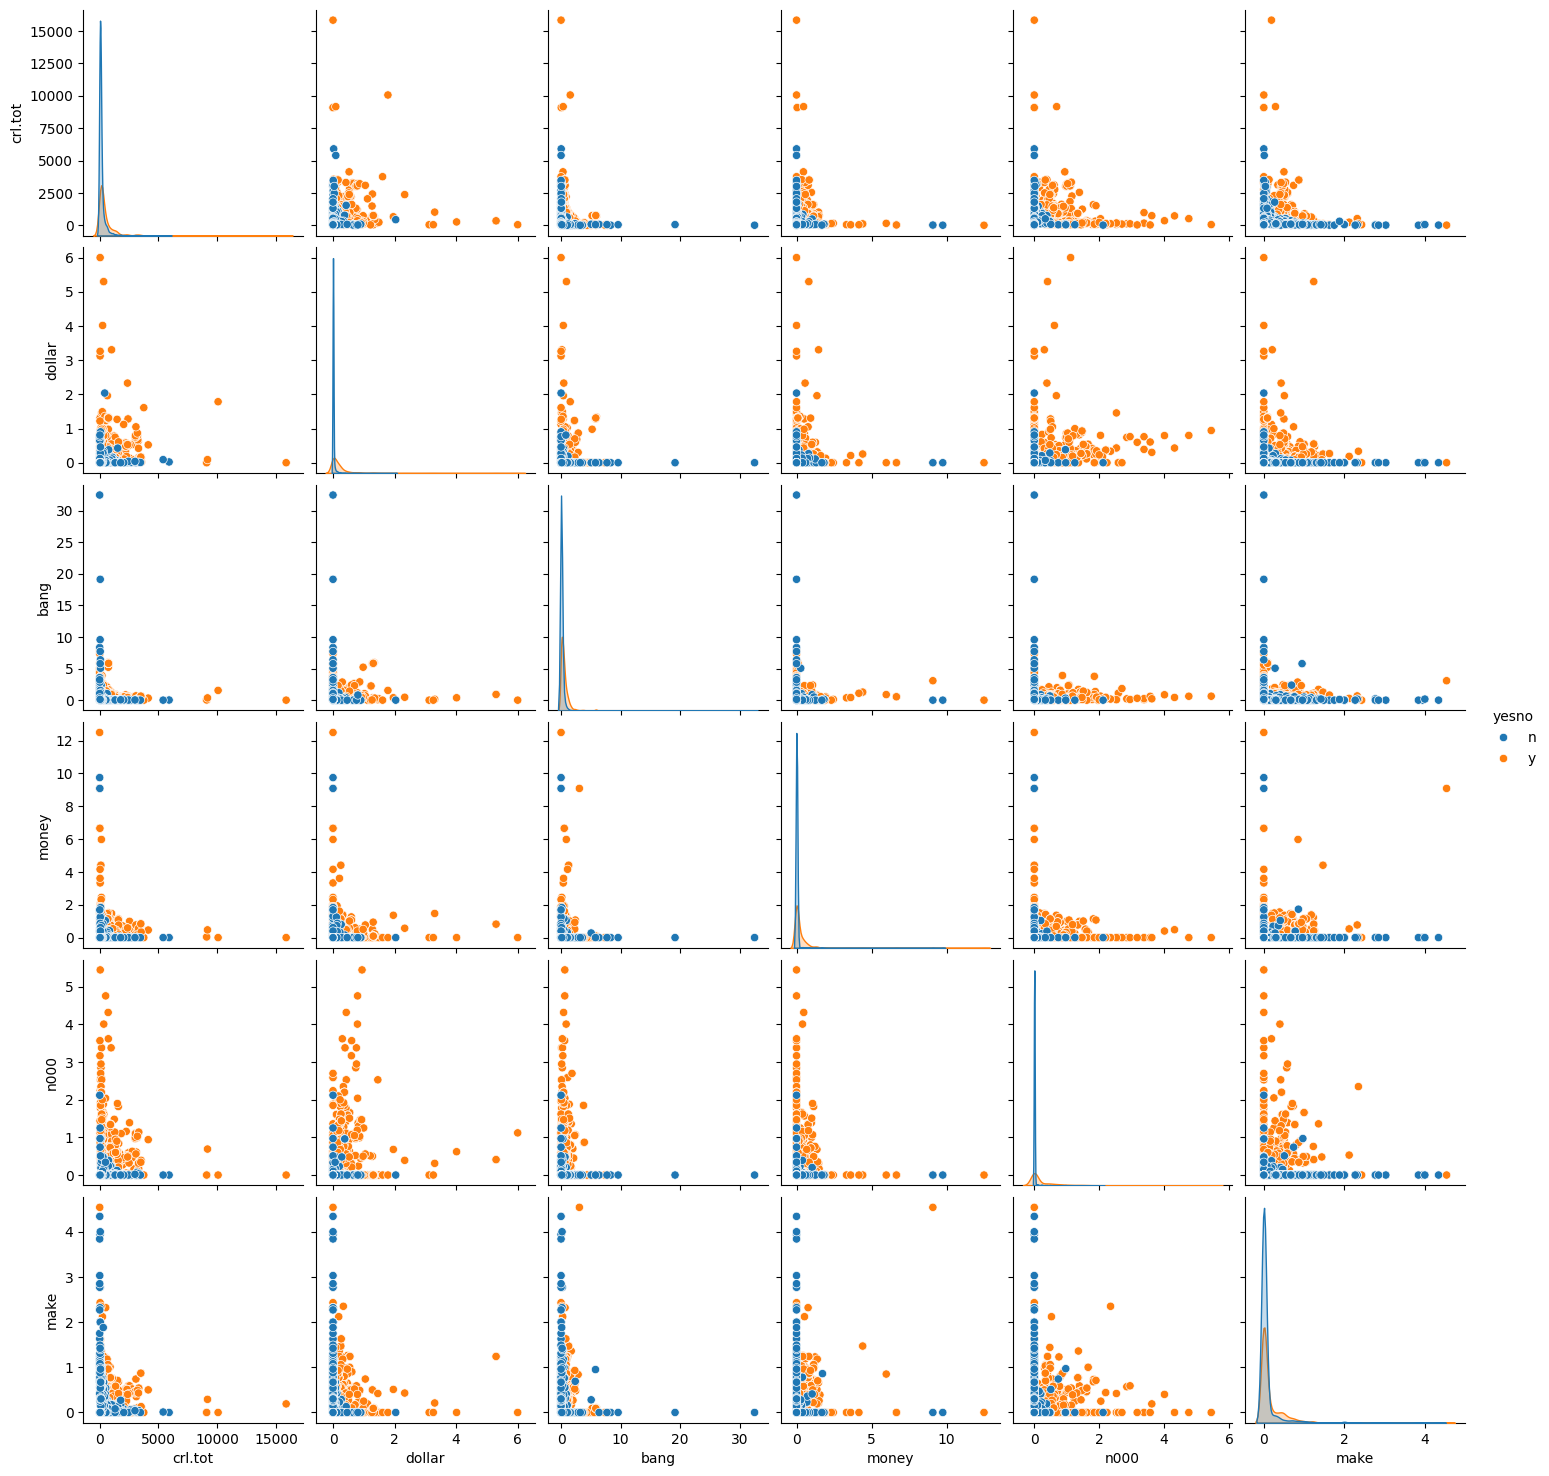

In [ ]:
sns.pairplot(data=spam, hue="yesno")